## 1. Importación de librerías

# Sistema de Recomendación de Productos
## Joyería Diana Laura — Content-Based Filtering (Similitud Coseno)

Este notebook implementa un sistema de recomendación basado en contenido.
El objetivo es recomendar productos similares al que el cliente acaba de comprar o está viendo,
comparando sus características físicas y de fabricación mediante similitud coseno.

In [6]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from dotenv import load_dotenv

load_dotenv()
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. Conexión a la base de datos

In [7]:
DATABASE_URL = os.getenv('DATABASE_URL')

conn = psycopg2.connect(DATABASE_URL)
print('✅ Conexión exitosa a Supabase')

✅ Conexión exitosa a Supabase


## 3. Extracción de productos

In [8]:
query = """
    SELECT
        p.id,
        p.nombre,
        p.material_principal,
        c.nombre AS categoria,
        p.peso_gramos,
        p.dias_fabricacion,
        p.permite_personalizacion
    FROM productos p
    JOIN categorias c ON p.categoria_id = c.id
    WHERE p.activo = true
    ORDER BY p.id
"""

df = pd.read_sql(query, conn)
print(f'✅ Total de productos obtenidos: {len(df)}')
df

✅ Total de productos obtenidos: 15


C:\Users\uriel\AppData\Local\Temp\ipykernel_31952\3722298894.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,nombre,material_principal,categoria,peso_gramos,dias_fabricacion,permite_personalizacion
0,1,Esclava personalizada Día del Padre,Plata,esclavas,6.2,0,True
1,2,Aretes corazón doble plata,Plata,Aretes,2.5,0,False
2,3,Pulsera personalizada Día del Niño,Acero/cuentas plásticas (bisutería),Pulseras,1.5,0,True
3,4,Esclava laminado de oro figaro,Laminado de oro,esclavas,12.5,0,False
4,6,Anillo plata solitario clásico,Plata,Anillos,4.5,0,False
5,8,Anillo plata piedra corazón rosa,Plata,Anillos,4.8,0,False
6,9,Anillo plata ley .925 corazón amatista,Plata ley .925,Anillos,5.5,0,False
7,10,Aretes plata ley .925 cristal azul y corazón f...,Plata ley .925,Aretes,3.0,0,False
8,11,Aretitos plata corazón filigrana morado,Plata,Aretes,2.1,0,False
9,12,Aretitos plata gota filigrana con perla,Plata,Aretes,2.3,0,False


## 4. Exploración de datos

In [9]:
print('=== RESUMEN DE DATOS ===')
print(f'Total de productos: {len(df)}')
print()
print('=== MATERIALES ===')
print(df['material_principal'].value_counts())
print()
print('=== CATEGORÍAS ===')
print(df['categoria'].value_counts())
print()
print('=== ESTADÍSTICAS NUMÉRICAS ===')
print(df[['peso_gramos', 'dias_fabricacion']].describe())

=== RESUMEN DE DATOS ===
Total de productos: 15

=== MATERIALES ===
material_principal
Plata                                  6
Plata ley .925                         4
Chapa de oro                           2
Acero/cuentas plásticas (bisutería)    1
Laminado de oro                        1
Baño en rodio                          1
Name: count, dtype: int64

=== CATEGORÍAS ===
categoria
Anillos     8
Aretes      4
esclavas    2
Pulseras    1
Name: count, dtype: int64

=== ESTADÍSTICAS NUMÉRICAS ===
       peso_gramos  dias_fabricacion
count    15.000000              15.0
mean      4.466667               0.0
std       2.650247               0.0
min       1.500000               0.0
25%       2.750000               0.0
50%       4.100000               0.0
75%       5.350000               0.0
max      12.500000               0.0


## 5. Preparación de variables (codificación)

In [10]:
df_features = df.copy()

# One-Hot Encoding para variables categoricas SIN orden real (material, categoria).
# LabelEncoder no es correcto aqui: asignaria numeros arbitrarios (ej. Plata=4, Oro=2)
# que el algoritmo interpretaria como si tuvieran una relacion de orden/distancia real
# entre materiales, lo cual no tiene sentido (Plata no esta 'mas cerca' de Oro que de Acero).
dummies_material = pd.get_dummies(df_features['material_principal'], prefix='material')
dummies_categoria = pd.get_dummies(df_features['categoria'], prefix='categoria')

df_features['personalizacion_enc'] = df['permite_personalizacion'].astype(int)

# Estandarizacion de las variables numericas (media 0, desviacion estandar 1).
# Sin este paso, peso_gramos (rango ~1 a 12) dominaria el calculo de similitud frente
# a las columnas binarias de One-Hot (rango 0 a 1), sesgando el resultado.
numericas = df_features[['peso_gramos', 'dias_fabricacion']]
numericas_escaladas = pd.DataFrame(
    StandardScaler().fit_transform(numericas),
    columns=['peso_gramos_esc', 'dias_fabricacion_esc'],
    index=df_features.index
)

# Matriz de caracteristicas final para similitud coseno
X = pd.concat([
    dummies_material,
    dummies_categoria,
    numericas_escaladas,
    df_features['personalizacion_enc']
], axis=1)

print('=== VARIABLES PREPARADAS (One-Hot + Estandarizacion) ===')
print(X)
print()
print(f'Dimensiones de la matriz de caracteristicas: {X.shape}')

X = X.values


=== VARIABLES PREPARADAS (One-Hot + Estandarizacion) ===
    material_Acero/cuentas plásticas (bisutería)  material_Baño en rodio  \
0                                          False                   False   
1                                          False                   False   
2                                           True                   False   
3                                          False                   False   
4                                          False                   False   
5                                          False                   False   
6                                          False                   False   
7                                          False                   False   
8                                          False                   False   
9                                          False                   False   
10                                         False                    True   
11                             

## 6. Cálculo de Similitud Coseno

In [11]:
sim_matrix = cosine_similarity(X)

sim_df = pd.DataFrame(sim_matrix, index=df['nombre'], columns=df['nombre'])

print(f'Dimensiones de la matriz de similitud: {sim_matrix.shape}')
print('(Cada celda indica qué tan similar es un producto con otro — 1.0 = idéntico)')
print()
print(sim_df.round(2))

Dimensiones de la matriz de similitud: (15, 15)
(Cada celda indica qué tan similar es un producto con otro — 1.0 = idéntico)

nombre                                              Esclava personalizada Día del Padre  \
nombre                                                                                    
Esclava personalizada Día del Padre                                                1.00   
Aretes corazón doble plata                                                         0.16   
Pulsera personalizada Día del Niño                                                 0.06   
Esclava laminado de oro figaro                                                     0.49   
Anillo plata solitario clásico                                                     0.38   
Anillo plata piedra corazón rosa                                                   0.41   
Anillo plata ley .925 corazón amatista                                             0.10   
Aretes plata ley .925 cristal azul y corazón fi...     

## 7. Visualización — Mapa de Calor de Similitud

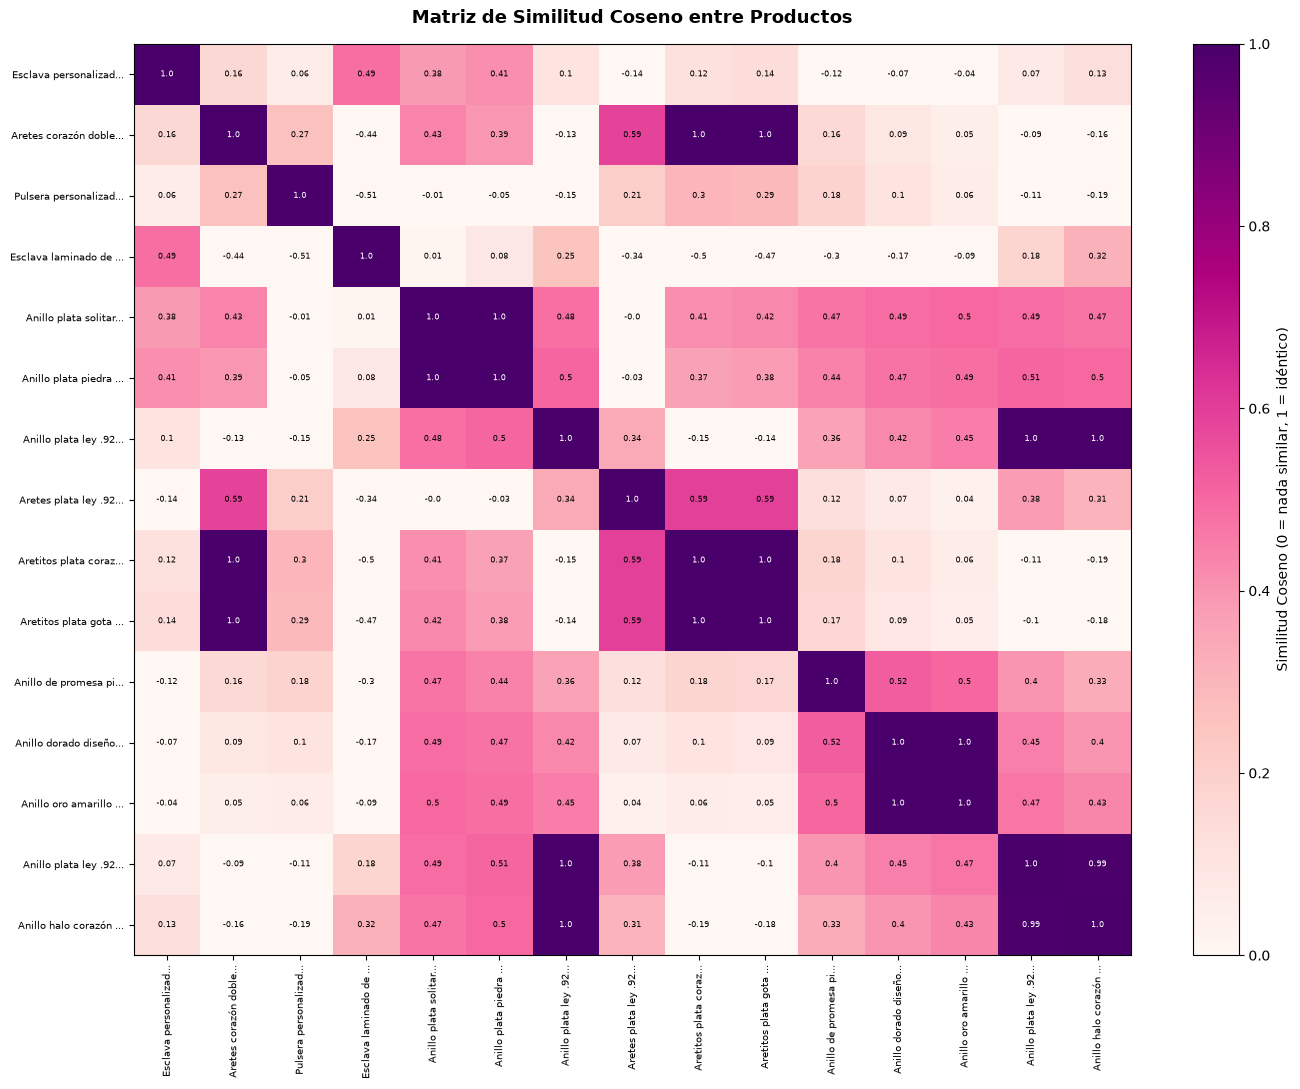

In [12]:
fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(sim_matrix, cmap='RdPu', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, label='Similitud Coseno (0 = nada similar, 1 = idéntico)')

nombres_cortos = [n[:20] + '...' if len(n) > 20 else n for n in df['nombre']]
ax.set_xticks(range(len(df)))
ax.set_yticks(range(len(df)))
ax.set_xticklabels(nombres_cortos, rotation=90, fontsize=7)
ax.set_yticklabels(nombres_cortos, fontsize=7)

for i in range(len(df)):
    for j in range(len(df)):
        val = round(sim_matrix[i, j], 2)
        color = 'white' if sim_matrix[i, j] > 0.6 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', fontsize=6, color=color)

ax.set_title('Matriz de Similitud Coseno entre Productos', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 8. Sistema de Recomendación

In [13]:
def recomendar(producto_id, df, sim_matrix, top_n=3):
    """
    Recomienda los productos más similares a un producto dado.
    producto_id: id del producto comprado/visto
    """
    # Encontrar el índice del producto en el dataframe
    indices = df[df['id'] == producto_id].index
    if len(indices) == 0:
        return []
    idx = indices[0]

    # Obtener similitudes con todos los demás productos
    similitudes = list(enumerate(sim_matrix[idx]))

    # Ordenar por similitud descendente, excluyendo el mismo producto
    similitudes = sorted(similitudes, key=lambda x: x[1], reverse=True)
    similitudes = [s for s in similitudes if s[0] != idx]

    # Retornar los top_n más similares
    top_indices = [s[0] for s in similitudes[:top_n]]
    resultado = df.iloc[top_indices][['id', 'nombre', 'material_principal', 'categoria']].copy()
    resultado['similitud'] = [round(similitudes[i][1], 4) for i in range(len(top_indices))]
    return resultado

print('✅ Función de recomendación lista')

✅ Función de recomendación lista


## 9. Prueba del sistema de recomendación

## 10. Guardar el modelo

In [14]:
# Prueba 1 — recomendar a partir del primer producto del catálogo
primer_id = df.iloc[0]['id']
primer_nombre = df.iloc[0]['nombre']
print(f'Producto visto: "{primer_nombre}"')
print()
recomendaciones = recomendar(primer_id, df, sim_matrix)
print('Recomendaciones:')
print(recomendaciones.to_string(index=False))
print()

# Prueba 2 — recomendar a partir del segundo producto
segundo_id = df.iloc[1]['id']
segundo_nombre = df.iloc[1]['nombre']
print(f'Producto visto: "{segundo_nombre}"')
print()
recomendaciones2 = recomendar(segundo_id, df, sim_matrix)
print('Recomendaciones:')
print(recomendaciones2.to_string(index=False))

Producto visto: "Esclava personalizada Día del Padre"

Recomendaciones:
 id                           nombre material_principal categoria  similitud
  4   Esclava laminado de oro figaro    Laminado de oro  esclavas     0.4881
  8 Anillo plata piedra corazón rosa              Plata   Anillos     0.4120
  6   Anillo plata solitario clásico              Plata   Anillos     0.3836

Producto visto: "Aretes corazón doble plata"

Recomendaciones:
 id                                                 nombre material_principal categoria  similitud
 12                Aretitos plata gota filigrana con perla              Plata    Aretes     0.9991
 11                Aretitos plata corazón filigrana morado              Plata    Aretes     0.9967
 10 Aretes plata ley .925 cristal azul y corazón filigrana     Plata ley .925    Aretes     0.5864


In [15]:
modelo = {
    'sim_matrix': sim_matrix,
    'df_productos': df
}

with open('modelo_recomendacion.pkl', 'wb') as f:
    pickle.dump(modelo, f)

print('✅ Modelo guardado como modelo_recomendacion.pkl')


✅ Modelo guardado como modelo_recomendacion.pkl


## 11. Conclusiones

El sistema de recomendación basado en **Content-Based Filtering con Similitud Coseno** fue implementado exitosamente para Joyería Diana Laura.

**¿Por qué Content-Based Filtering?**
En una joyería los clientes generalmente compran 1 pieza por visita, lo que hace que las reglas de asociación (Apriori) no sean adecuadas al requerir múltiples productos por transacción. Content-Based Filtering resuelve esto comparando los atributos de los productos entre sí, sin depender de cuántos artículos se compren juntos.

**Variables utilizadas (X):**
- `material_principal` — el material define características físicas y de precio (codificado con **One-Hot Encoding**, no LabelEncoder, porque no existe un orden real entre materiales)
- `categoria` — aretes, anillos, esclavas, pulseras (también con **One-Hot Encoding**)
- `peso_gramos` — cantidad de material utilizado (**estandarizado** con `StandardScaler`)
- `dias_fabricacion` — complejidad del producto (**estandarizado** con `StandardScaler`)
- `permite_personalizacion` — si requiere trabajo adicional (binaria 0/1)

**¿Por qué One-Hot Encoding y no LabelEncoder?**
`LabelEncoder` asigna números arbitrarios a categorías (ej. Plata=4, Oro=2), lo cual el algoritmo interpretaría como si esos materiales tuvieran una relación de orden o distancia real entre sí — cosa que no tiene sentido en variables nominales. One-Hot Encoding evita ese problema al representar cada categoría como una columna binaria independiente.

**¿Por qué estandarizar `peso_gramos` y `dias_fabricacion`?**
Sin estandarizar, `peso_gramos` (rango ~1 a 12) dominaría el cálculo de similitud frente a las columnas binarias de One-Hot (rango 0 a 1), sesgando el resultado hacia el peso y restándole peso real a material/categoría.

**Cómo funciona:**
1. Cada producto se representa como un vector de características numéricas (One-Hot + variables estandarizadas)
2. La similitud coseno mide el ángulo entre dos vectores — entre más cercano a 1, más similares son los productos
3. Cuando un cliente compra o ve un producto, el sistema devuelve los N productos con mayor similitud

**Sobre el `modelo_recomendacion.pkl`:** se guarda como evidencia de que el modelo fue entrenado y serializado correctamente, pero el microservicio Flask en producción **no lo carga** — recalcula la similitud coseno en tiempo real en cada solicitud, consultando la base de datos directamente. Esto se decidió así porque el catálogo cambia con frecuencia (altas de productos) y el volumen de datos es pequeño, por lo que recalcular en vivo es prácticamente gratis y siempre refleja el catálogo actualizado, sin necesidad de reentrenar y volver a desplegar el `.pkl` cada vez.
